In [11]:
!pip install ultralytics opencv-python matplotlib

In [12]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
model = YOLO("yolo11n-pose.pt")

In [22]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving IMG_2206.HEIC to IMG_2206.HEIC


In [24]:
results = model(image_path)


image 1/1 /content/IMG_2206.HEIC: 640x480 1 person, 198.9ms
Speed: 3.9ms preprocess, 198.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


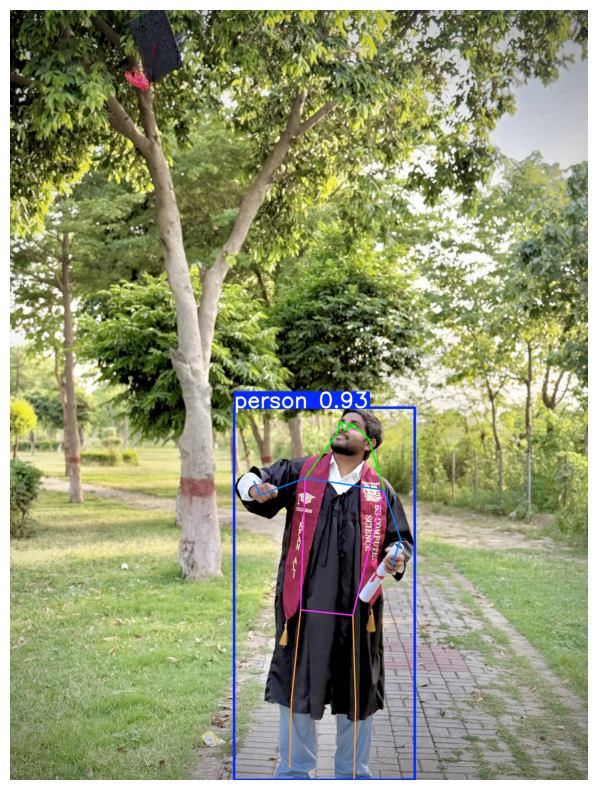

In [25]:
annotated = results[0].plot()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [26]:
keypoints = results[0].keypoints.xy.cpu().numpy()

print(keypoints.shape)
print(keypoints)

(1, 17, 2)
[[[       1749      2198.8]
  [     1800.3        2174]
  [     1728.7      2161.7]
  [     1878.6      2247.1]
  [     1710.3      2219.8]
  [     1957.2      2514.3]
  [     1544.3      2451.9]
  [     2043.8      2770.2]
  [     1308.1      2539.1]
  [     1998.3      2910.5]
  [     1278.2      2472.5]
  [       1793      3169.8]
  [     1520.4      3141.7]
  [     1808.7      3642.5]
  [     1472.6      3612.8]
  [     1800.8      4020.4]
  [     1463.8      3961.1]]]


In [27]:
person = keypoints[0]

for i, point in enumerate(person):
    print(f"Keypoint {i}: {point}")

Keypoint 0: [       1749      2198.8]
Keypoint 1: [     1800.3        2174]
Keypoint 2: [     1728.7      2161.7]
Keypoint 3: [     1878.6      2247.1]
Keypoint 4: [     1710.3      2219.8]
Keypoint 5: [     1957.2      2514.3]
Keypoint 6: [     1544.3      2451.9]
Keypoint 7: [     2043.8      2770.2]
Keypoint 8: [     1308.1      2539.1]
Keypoint 9: [     1998.3      2910.5]
Keypoint 10: [     1278.2      2472.5]
Keypoint 11: [       1793      3169.8]
Keypoint 12: [     1520.4      3141.7]
Keypoint 13: [     1808.7      3642.5]
Keypoint 14: [     1472.6      3612.8]
Keypoint 15: [     1800.8      4020.4]
Keypoint 16: [     1463.8      3961.1]


In [31]:
# COCO keypoints
# 5 = Left Shoulder
# 7 = Left Elbow
# 9 = Left Wrist

shoulder = person[5]
elbow = person[7]
wrist = person[9]

angle = calculate_angle(
    shoulder,
    elbow,
    wrist
)

print("Left Elbow Angle:", angle)

Left Elbow Angle: 143.3114


In [33]:
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

Saving video-for-pose-detection-1-1080x1920-30fps.mp4 to video-for-pose-detection-1-1080x1920-30fps.mp4


In [34]:
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)

    annotated = results[0].plot()

    out.write(annotated)

cap.release()
out.release()

print("Done!")


0: 640x384 1 person, 425.0ms
Speed: 7.5ms preprocess, 425.0ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 311.1ms
Speed: 16.4ms preprocess, 311.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 158.6ms
Speed: 4.6ms preprocess, 158.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 160.6ms
Speed: 3.7ms preprocess, 160.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 165.7ms
Speed: 3.8ms preprocess, 165.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 153.6ms
Speed: 5.5ms preprocess, 153.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 155.5ms
Speed: 4.5ms preprocess, 155.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 163.1ms
Speed: 3.9ms preprocess, 163.1ms inference, 1.5ms postprocess per image a

In [35]:
from google.colab import files

files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
def squat_stage(hip, knee, ankle):

    angle = calculate_angle(
        hip,
        knee,
        ankle
    )

    if angle > 160:
        return "Standing"

    elif angle < 100:
        return "Squatting"

    else:
        return "Transition"

In [37]:
hip = person[11]
knee = person[13]
ankle = person[15]

print(
    squat_stage(
        hip,
        knee,
        ankle
    )
)

Standing
